## Import statements

In [2]:
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs

In [3]:
import pop_tools
import xarray as xr
import numpy as np
import cftime
import xesmf as xe
import cmocean
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
from scipy.signal import coherence, csd
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from scipy.stats import linregress
import pandas as pd

import warnings
warnings.filterwarnings('ignore')  # Add this at the top of your script

## Functions

In [4]:
def make_ds(data):
    data_ds = xr.DataArray(
        np.array(data), 
        dims=('time', 'nlat', 'nlon'), 
        coords={
            'time': data.time,
            'nlat': data.ULAT.mean(dim='nlon'), 
            'nlon': data.ULONG.mean(dim='nlat')})
    return data_ds

In [5]:
def standardize(data):
    return (data - data.mean()) / data.std()

In [6]:
def LENS_for_regridding():
    # LENS for regridding purposes
    ens_memb_index = 0
    comp = 'atm'; var = 'AREA'
    directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
    
    ds_var_hist_var, ds_var_fut_var = cesm2_lens_utils.get_ds_var(
        directory, var=var,comp=comp, 
        index_hist = ens_memb_index)
    
    # FOSI is from 1958 to 2020
    CESMLENS_hist_var = ds_var_hist_var[var].sel(time=slice('1958-01', '2015-01')).compute()
    CESMLENS_fut_var = ds_var_fut_var[var].sel(time=slice('2015-02', '2020-12')).compute()
    
    CESMLENS_var = xr.concat(
        [CESMLENS_hist_var, CESMLENS_fut_var], 
        dim='time')
    return CESMLENS_var

In [7]:
def calculate_DII(precip_ds):
    mean_Prec_N = precip_ds.sel(lat=slice(0,20), lon=slice(150, 270)).mean(dim=('lat','lon'))
    mean_Prec_S = precip_ds.sel(lat=slice(-20,0), lon=slice(150, 270)).mean(dim=('lat','lon'))
    mean_Prec_NS = precip_ds.sel(lat=slice(-20,20), lon=slice(150, 270)).mean(dim=('lat','lon'))
    DII = (mean_Prec_N - mean_Prec_S) / mean_Prec_NS
    return DII

In [8]:
def remove_climatology(ds):
    ds_climatology = ds.groupby("time.month").mean("time")
    ds_anomalies = ds.groupby("time.month") - ds_climatology
    return ds_anomalies

In [9]:
def ocn_var_ens(ens_ind, VAR):
    COMP = 'ocn'
    DIRECTORY = f'/glade/campaign/cgd/cesm/CESM2-LE/{COMP}/proc/tseries/month_1/{VAR}/'
    ds_var_hist_var, ds_var_fut_var = cesm2_lens_utils.get_ds_var(
        directory=DIRECTORY, var=VAR, comp=COMP, index_hist = ens_ind)
    var_ds = ds_var_hist_var[VAR].sel(time=slice('1958-01', '2015-01'))
    return var_ds

In [85]:
def load_PV_lens(ens_ind):
    PV_lens = ocn_var_ens(ens_ind, 'PV')
    PV_Lens_compute = PV_lens.isel(z_t = 15).compute()
    fosi_1deg_wzeros_var = proc_utils.regrid_SMYLE(PV_Lens_compute)
    regridded_PV_lens = regridder(fosi_1deg_wzeros_var)
    return regridded_PV_lens

## 0.3: CESM2-FOSI

### 0.3.0 Set up

In [11]:
# LENS for regridding purposes
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

#### FOSI set up
firstyear = 1959
lastyear = 2020
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]

### 0.3.1 Precipitation and DII
- regridded_PREC_F
- DII_FOSI
- DII_FOSI_anomalies

In [14]:
PREC_F = proc_utils.process_fosi_atm_var('PREC_F', fosi_montime_vals)

regridder = xe.Regridder(PREC_F, CESMLENS_var[:,:,:], 'nearest_s2d', periodic=True)

regridded_PREC_F = regridder(PREC_F).sel(time=slice('1958-01', '2020-12'))
regridded_PREC_F['time'] = CESMLENS_var.sel(time=slice('1958-01', '2020-12'))['time']

area_weighted_PREC_F = regridded_PREC_F*CESMLENS_var
DII_FOSI = afuncs.calculate_DII(area_weighted_PREC_F)
DII_FOSI_anomalies = afuncs.remove_climatology(DII_FOSI)

In [18]:
DII = xr.open_dataset(
    'DII_results/area_avg_DII_all_members.nc').__xarray_dataarray_variable__
time = DII.time.dt.year + DII.time.dt.month/12

In [28]:
DII_LENS_anomalies = afuncs.remove_climatology(DII)

In [26]:
data = DII_FOSI.rolling(time=12*8, center=True).mean().sel(time=slice('1958-01','2010-01'))
time_new = data.time.dt.year + data.time.dt.month/12


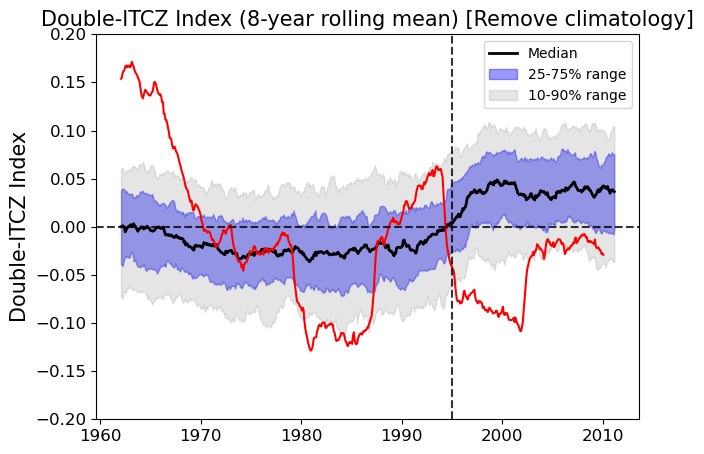

In [34]:
plt.figure(figsize=(7, 5))

percentiles = DII_LENS_anomalies.rolling(time=12*8, center=True).mean().quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9], dim='ensemble_member'
)

plt.plot(time, percentiles.sel(quantile=0.5), color='black', linewidth=2, label='Median')
plt.fill_between(time,
                percentiles.sel(quantile=0.25),
                percentiles.sel(quantile=0.75),
                alpha=0.4, color='blue', label='25-75% range')
plt.fill_between(time,
                percentiles.sel(quantile=0.1),
                percentiles.sel(quantile=0.9),
                alpha=0.2, color='gray', label='10-90% range')

plt.plot(time_new, DII_FOSI_anomalies.rolling(time=12*8, center=True).mean().sel(time=slice('1958-01','2010-01'))
, c='red')
plt.title('Double-ITCZ Index (8-year rolling mean) [Remove climatology]', fontsize=15)
plt.ylabel('Double-ITCZ Index', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.axvline(x=1995,c='k', linestyle='dashed', alpha=0.8)
plt.axhline(y=0, c='k', linestyle='dashed', alpha=0.8)
plt.ylim(-0.20, 0.20)
plt.show()

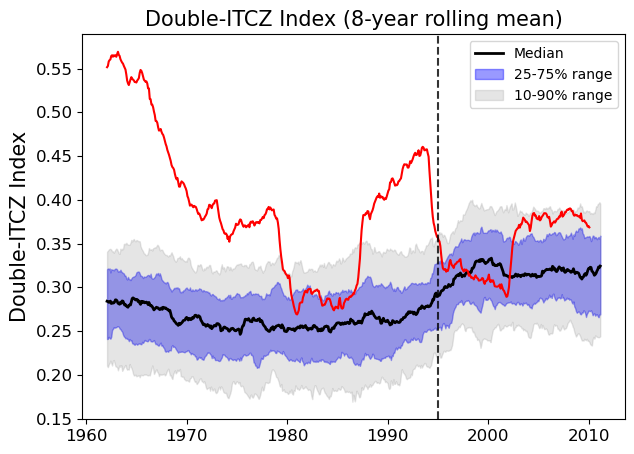

In [27]:
plt.figure(figsize=(7, 5))

percentiles = DII.rolling(time=12*8, center=True).mean().quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9], dim='ensemble_member'
)

plt.plot(time, percentiles.sel(quantile=0.5), color='black', linewidth=2, label='Median')
plt.fill_between(time,
                percentiles.sel(quantile=0.25),
                percentiles.sel(quantile=0.75),
                alpha=0.4, color='blue', label='25-75% range')
plt.fill_between(time,
                percentiles.sel(quantile=0.1),
                percentiles.sel(quantile=0.9),
                alpha=0.2, color='gray', label='10-90% range')

plt.plot(time_new, DII_FOSI.rolling(time=12*8, center=True).mean().sel(time=slice('1958-01','2010-01'))
, c='red')
plt.title('Double-ITCZ Index (8-year rolling mean)', fontsize=15)
plt.ylabel('Double-ITCZ Index', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.axvline(x=1995,c='k', linestyle='dashed', alpha=0.8)
plt.show()

### 0.3.2 Wind stress (zonal and meridional), wind stress curl, Ekman upwelling velocity
- regridded_TAUX
- regridded_TAUY
- curl_tau
- w_ek

In [6]:
TAUX_dyne_cm2 = proc_utils.process_fosi_atm_var('TAUX', fosi_montime_vals)
TAUY_dyne_cm2 = proc_utils.process_fosi_atm_var('TAUY', fosi_montime_vals)

regridded_TAUX = regridder(TAUX_dyne_cm2)
regridded_TAUY = regridder(TAUY_dyne_cm2)

# Define constants
RHO = 1025  # kg/m^3
OMEGA = 7.2921e-5  # rad/s
F = 2 * OMEGA * np.sin(np.deg2rad(regridded_TAUX.lat)) # Coriolis parameter f

TAUX_SI = regridded_TAUX / 10
TAUY_SI = regridded_TAUY / 10

dlon = np.deg2rad(np.diff(TAUX_SI.lon)[0]) # assumes uniform grid, get dlon in radians
dlat = np.deg2rad(np.diff(TAUX_SI.lat)[0]) # assumes uniform grid, get dlat in radians

earth_radius = 6.371e6 # meters
dx = earth_radius * np.cos(np.deg2rad(TAUX_SI.lat)) * dlon
dy = earth_radius * TAUX_SI.lat

d_TAUY_dx = TAUY_SI.differentiate('lon') / dx
d_TAUX_dy = TAUX_SI.differentiate('lat') / dy

curl_tau = d_TAUY_dx - d_TAUX_dy
w_ek = curl_tau / (RHO * np.abs(F)) # Standard formula

###  0.3.3 Solar shortwave heat flux and surface heat flux
- regridded_SHF_QSW
- regridded_SHF

In [7]:
##### SHF_QSW = Solar Short-Wave Heat Flux
SHF_QSW = proc_utils.process_fosi_atm_var('SHF_QSW', fosi_montime_vals)
regridded_SHF_QSW = regridder(SHF_QSW)

##### SHF = Solar Short-Wave Heat Flux
SHF = proc_utils.process_fosi_atm_var('SHF', fosi_montime_vals)
regridded_SHF = regridder(SHF)

### 0.3.3 Sea surface temperature
- regridded_temp

In [8]:
##### TEMP (SST)
field = 'TEMP'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi_temp = xr.open_dataset(fpath+fname)[field].isel(z_t = 0)
ds_smyle_fosi_temp['time'] = fosi_montime_vals
temp_fosi = ds_smyle_fosi_temp.compute()
fosi_anom_1deg_wzeros_temp = proc_utils.regrid_SMYLE(temp_fosi)
fosi_anom_1deg_temp = fosi_anom_1deg_wzeros_temp.where(
    fosi_anom_1deg_wzeros_temp!=0, np.nan)
regridded_temp = regridder(fosi_anom_1deg_temp)

## 0.3.4: Transport branches

In [12]:
nlat_ind_ls = [114,117,120,123,127,130,134,137,
               141,145,149,152,156,160,164,167,171,175,179,
               182,186,190,194,197,201,205,209,213,216,220,224,228]

wbc_boundary_nlon_indx_ls = [64, 65, 80, 54, 79, 48, 48, 48, 56, 56, 
                             55, 55, 55, 54, 55, 55, 54, 57, 53, 51, 
                             53, 52, 34, 34, 35, 33, 31, 32, 32, 32, 
                             31, 31] # WBC from piControl

In [10]:
# upwelling branch
upwelling_branch_transport = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_upwelling_upper_transport.nc')
upwelling_branch_ds = afuncs.make_ds(upwelling_branch_transport.__xarray_dataarray_variable__)

# surface layer
surface_layer_transport = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_upper_transport.nc')
surface_layer_ds = afuncs.make_ds(surface_layer_transport.__xarray_dataarray_variable__)

# subsurface layer
subsurface_toeq_layer_transport = xr.open_dataset('/glade/derecho/scratch/cassiacai/fosi_equatorward_branch.nc')
subsur_toeq_transport_ds = afuncs.make_ds(subsurface_toeq_layer_transport.__xarray_dataarray_variable__)

In [12]:
field = 'TEMP'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'

dxu_in_cm_lat = xr.open_dataset(fpath+fname).DXU[nlat_ind_ls, 120:295].compute()
dz_in_cm = xr.open_dataset(fpath+fname).dz.isel(z_t = slice(5,33)).compute()

# meridional volume transport
CONVERSION_FACTOR = (0.01 ** 3) / 1e6  # m^3/s to Sv 

pd_start = xr.open_dataset(f'/glade/derecho/scratch/cassiacai/fosi_pd_ts_0_300.nc').PD
pd_end = xr.open_dataset(f'/glade/derecho/scratch/cassiacai/fosi_pd_ts_300_end.nc').PD
fosi_pd = xr.concat([pd_start, pd_end], dim='time')[:]

vvel_start = xr.open_dataset(f'/glade/derecho/scratch/cassiacai/fosi_vvel_ts_0_300.nc').VVEL
vvel_end = xr.open_dataset(f'/glade/derecho/scratch/cassiacai/fosi_vvel_ts_300_end.nc').VVEL
fosi_vvel = xr.concat([vvel_start, vvel_end], dim='time')[:]

sigma_theta = fosi_pd * 1000 - 1000 # convert to sigma_theta (kg/m³)
stc_mask = (sigma_theta >= 25.5) & (sigma_theta <= 26.5)

ds_STC_layer = fosi_pd.where(stc_mask)
vvel_lat_layer = fosi_vvel.where(stc_mask)

transport = vvel_lat_layer[:, :, :] * dxu_in_cm_lat * dz_in_cm  # shape: time x z x lon
integrated_transport = transport.sum(dim='z_t')  # shape: time x lon
transport_Sv = integrated_transport * CONVERSION_FACTOR  # m³/s → Sv
transport_Sv_nan = xr.where(transport_Sv == 0., np.nan, transport_Sv)

In [15]:
surface_layer_ds_ulong = surface_layer_ds.assign_coords(
    ULONG=(('nlat', 'nlon'), transport_Sv_nan['ULONG'].values))

all_ts = []
for lat_ind in range(31):
    ts = surface_layer_ds_ulong[:, lat_ind, :].dropna(dim='nlon').integrate('ULONG')
    all_ts.append(ts)

surf_ds = xr.DataArray(
    np.array(all_ts), dims=('lat', 'time'), coords={'lat': np.linspace(-20, 10, 31), 'time': surface_layer_ds.time})

In [16]:
upwelling_branch_ds_ulong = upwelling_branch_ds.assign_coords(
    ULONG=(('nlat', 'nlon'), transport_Sv_nan['ULONG'].values))

all_ts = []
for lat_ind in range(31):
    ts = upwelling_branch_ds_ulong[:, lat_ind, :].dropna(dim='nlon').integrate('ULONG')
    all_ts.append(ts)

upwell_ds = xr.DataArray(
    np.array(all_ts), dims=('lat', 'time'), coords={'lat': np.linspace(-20, 10, 31), 'time': upwelling_branch_ds.time})

In [17]:
all_int = []; all_wbc = []
for lat_ind in range(31):
    int_ts = transport_Sv_nan[:, lat_ind, wbc_boundary_nlon_indx_ls[lat_ind]:].dropna(dim='nlon').integrate('ULONG')
    wbc_ts = transport_Sv_nan[:, lat_ind, :wbc_boundary_nlon_indx_ls[lat_ind]].dropna(dim='nlon').integrate('ULONG')
    all_int.append(int_ts)
    all_wbc.append(wbc_ts)

int_ds = xr.DataArray(np.array(all_int), 
                         dims=('lat', 'time'), 
                         coords={'lat': np.linspace(-20, 10, 31), 'time': transport_Sv_nan.time})
wbc_ds = xr.DataArray(np.array(all_wbc), 
                         dims=('lat', 'time'),
                         coords={'lat': np.linspace(-20, 10, 31),  'time': transport_Sv_nan.time})

### Southeast Pacific region

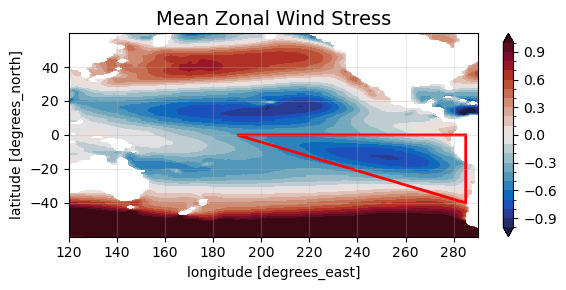

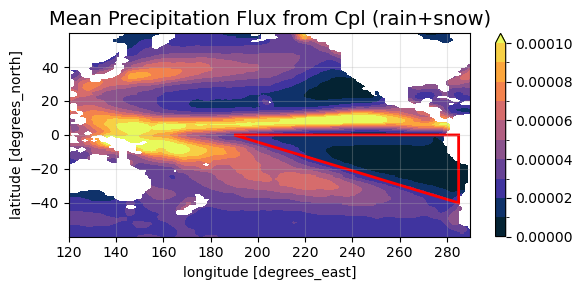

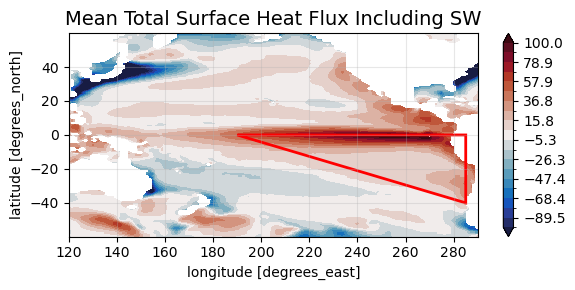

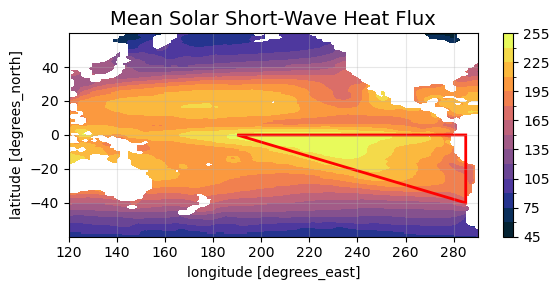

In [116]:
##############
fig, ax = plt.subplots(figsize=(6, 3))
im = regridded_TAUX.sel(lat=slice(-60, 60), lon=slice(120, 290)).mean(dim='time').plot.contourf(
    levels=21, ax=ax, add_colorbar=True, cmap=cmocean.cm.balance, 
   vmin=-1., vmax=1.)
vertices = np.array([[190, 0], [285, 0], [285, -40]])
polygon = Polygon(vertices, closed=True, fill=False, edgecolor='red', linewidth=2, label='Study Region')
ax.add_patch(polygon)
ax.set_title('Mean Zonal Wind Stress', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##############
fig, ax = plt.subplots(figsize=(6, 3))
im = regridded_PREC_F.sel(lat=slice(-60, 60), lon=slice(120, 290)).mean(dim='time').plot.contourf(
    levels=11, ax=ax, add_colorbar=True, cmap=cmocean.cm.thermal, 
   vmin=0, vmax=0.0001)
vertices = np.array([[190, 0], [285, 0], [285, -40]])
polygon = Polygon(vertices, closed=True, fill=False, edgecolor='red', linewidth=2, label='Study Region')
ax.add_patch(polygon)
ax.set_title('Mean Precipitation Flux from Cpl (rain+snow)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##############
fig, ax = plt.subplots(figsize=(6, 3))
im = regridded_SHF.sel(lat=slice(-60, 60), lon=slice(120, 290)).mean(dim='time').plot.contourf(
    levels=20, ax=ax, add_colorbar=True, cmap=cmocean.cm.balance, 
    vmin=-100, vmax=100)
vertices = np.array([[190, 0], [285, 0], [285, -40]])
polygon = Polygon(vertices, closed=True, fill=False, edgecolor='red', linewidth=2, label='Study Region')
ax.add_patch(polygon)
ax.set_title('Mean Total Surface Heat Flux Including SW', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##############
fig, ax = plt.subplots(figsize=(6, 3))
im = regridded_SHF_QSW.sel(lat=slice(-60, 60), lon=slice(120, 290)).mean(dim='time').plot.contourf(
    levels=20, ax=ax, add_colorbar=True, cmap=cmocean.cm.thermal)
vertices = np.array([[190, 0], [285, 0], [285, -40]])
polygon = Polygon(vertices, closed=True, fill=False, edgecolor='red', linewidth=2, label='Study Region')
ax.add_patch(polygon)
ax.set_title('Mean Solar Short-Wave Heat Flux', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
vertices = np.array([[190, 0], [285, 0], [285, -40]  ])
SEP_mask = proc_utils.create_region_mask(
    lon=regridded_PREC_F.lon.values, lat=regridded_PREC_F.lat.values,vertices=vertices)
time = regridded_PREC_F.time.dt.year + regridded_PREC_F.time.dt.month/12

In [20]:
# calculate anomalies
regridded_PREC_F_anomalies = afuncs.remove_climatology(regridded_PREC_F)
SEP_PREC_F_anom = regridded_PREC_F_anomalies.where(SEP_mask)

regridded_SST_anomalies = afuncs.remove_climatology(regridded_temp)
SEP_SST_anom = regridded_SST_anomalies.where(SEP_mask)

regridded_SHF_anomalies = afuncs.remove_climatology(regridded_SHF)
SEP_SHF_anom = regridded_SHF_anomalies.where(SEP_mask)

regridded_SHF_QSW_anomalies = afuncs.remove_climatology(regridded_SHF_QSW)
SEP_SHF_QSW_anom = regridded_SHF_QSW_anomalies.where(SEP_mask)

regridded_TAUX_anomalies = afuncs.remove_climatology(regridded_TAUX)

surf_branch_anom = afuncs.remove_climatology(surf_ds)
upwelling_branch_anom = afuncs.remove_climatology(upwell_ds)
int_anom = afuncs.remove_climatology(int_ds)
wbc_anom = afuncs.remove_climatology(wbc_ds)

In [ ]:
# Zonally integrated TAUX and PREC_F
zi_TAUX_anom = (regridded_TAUX_anomalies.sel(lat=slice(-50, 50), lon=slice(120, 290)).fillna(0).integrate('lon'))
zi_TAUX = (regridded_TAUX.sel(lat=slice(-50, 50), lon=slice(120, 290)).fillna(0).integrate('lon'))

zi_PREC_F_anom = (regridded_PREC_F_anomalies.sel(lat=slice(-50, 50), lon=slice(120, 290)).fillna(0).integrate('lon'))
zi_PREC_F = (regridded_PREC_F.sel(lat=slice(-50, 50), lon=slice(120, 290)).fillna(0).integrate('lon'))

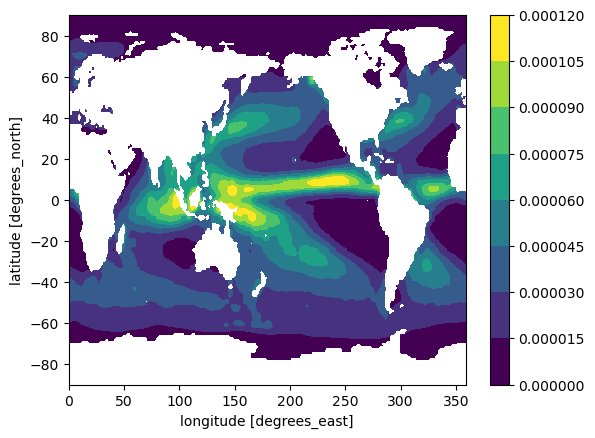

In [84]:
regridded_PREC_F.mean(dim='time').plot.contourf(levels=10)

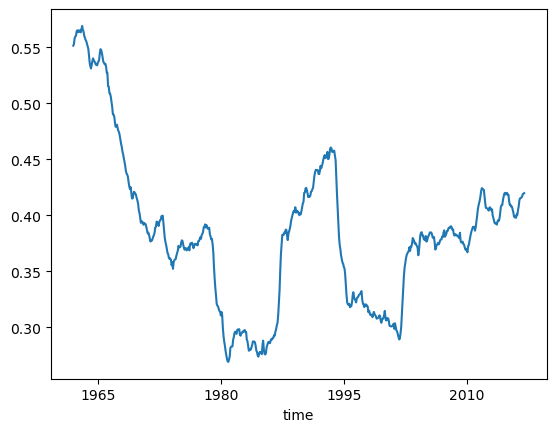

In [94]:
DII_FOSI.rolling(time=12*8, center=True).mean().plot()

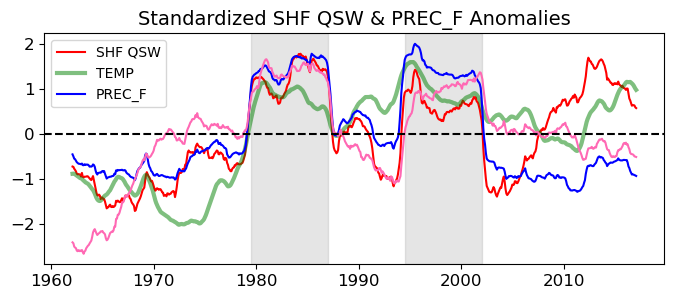

In [37]:
plt.figure(figsize=(8, 3))
plt.title('Standardized SHF QSW & PREC_F Anomalies', fontsize=14)
plt.plot(time, afuncs.standardize(SEP_SHF_QSW_anom.mean(dim=["lat", "lon"]).rolling(
    time=12*8, center=True).mean()*-1), c='red', label='SHF QSW')
plt.plot(time, afuncs.standardize(SEP_SST_anom.mean(dim=["lat", "lon"]).rolling(
    time=12*8, center=True).mean()), c='green', linewidth=3, alpha=0.5, label='TEMP')
plt.plot(time, afuncs.standardize(SEP_PREC_F_anom.mean(dim=["lat", "lon"]).rolling(
    time=12*8, center=True).mean()), c='blue', label='PREC_F')
plt.plot(time, 
         afuncs.standardize(DII_FOSI_anomalies.rolling(time=12*8, center=True).mean()*-1), c='hotpink')

plt.axhline(y=0, c='k', linestyle='dashed')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()

plt.axvspan(1979.5, 1987, alpha=0.2, color='gray')
plt.axvspan(1994.5, 2002, alpha=0.2, color='gray')
plt.show()

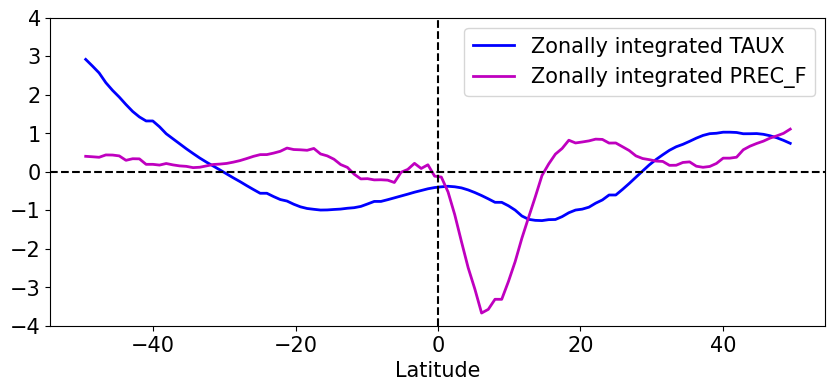

In [40]:
plt.figure(figsize=(10, 4))
afuncs.standardize(zi_TAUX.mean(dim='time')).plot(c='blue', linewidth=2, label='Zonally integrated TAUX')
afuncs.standardize(zi_PREC_F.mean(dim='time')*-1).plot(c='m', linewidth=2, label='Zonally integrated PREC_F')
plt.ylim(-4, 4)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.axvline(x=0, c='k', linestyle='dashed')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Latitude', fontsize=15)
plt.legend(fontsize=15)
plt.show()

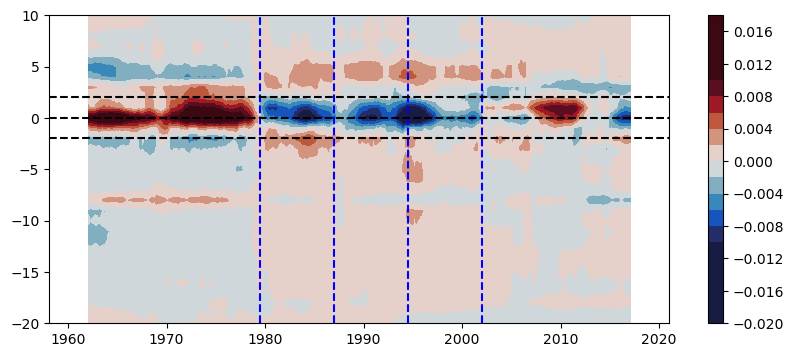

In [46]:
plt.figure(figsize=(10, 4))
plt.contourf(
    time, 
    upwelling_branch_anom.lat, 
    upwelling_branch_anom.rolling(time=12*8, center=True).mean(),
    vmin=-0.01, vmax=0.01, cmap=cmocean.cm.balance, levels=21)
plt.axvline(x=1979.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1987, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1994.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=2002, alpha=1, color='blue',linestyle='dashed')
plt.axhline(y=0, c='k', linestyle='dashed')
plt.axhline(y=-2, c='k', linestyle='dashed')
plt.axhline(y=2, c='k', linestyle='dashed')
plt.colorbar()
plt.show()

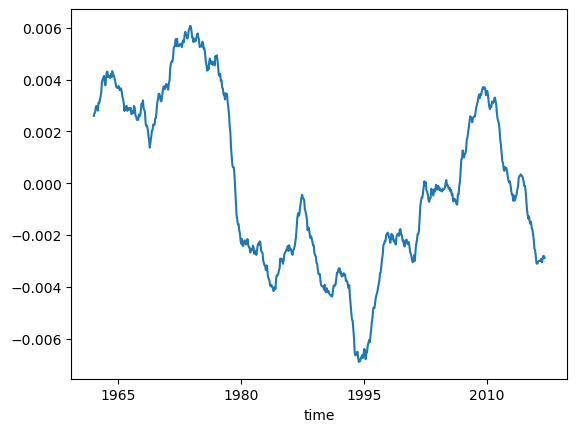

In [54]:
upwelling_branch_anom.sel(lat=slice(-2, 2)).mean(dim='lat').rolling(time=12*8, center=True).mean().plot()

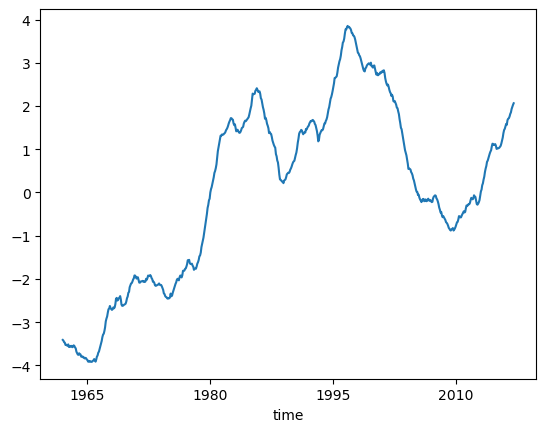

In [57]:
wbc_anom.sel(lat=slice(-20, -10)).mean(dim='lat').rolling(time=12*8, center=True).mean().plot()

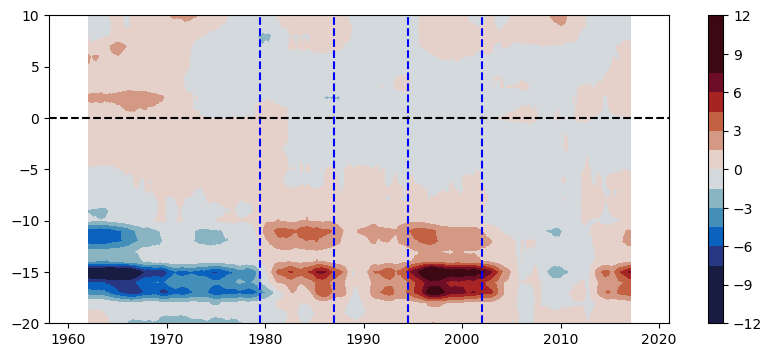

In [359]:
plt.figure(figsize=(10, 4))
plt.contourf(
    time, 
    wbc_anomalies.lat, 
    wbc_anomalies.rolling(time=12*8, center=True).mean(),
    vmin=-8, vmax=8, cmap=cmocean.cm.balance, levels=21)
plt.axvline(x=1979.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1987, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1994.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=2002, alpha=1, color='blue',linestyle='dashed')
plt.axhline(y=0, c='k', linestyle='dashed')
plt.colorbar()
plt.show()

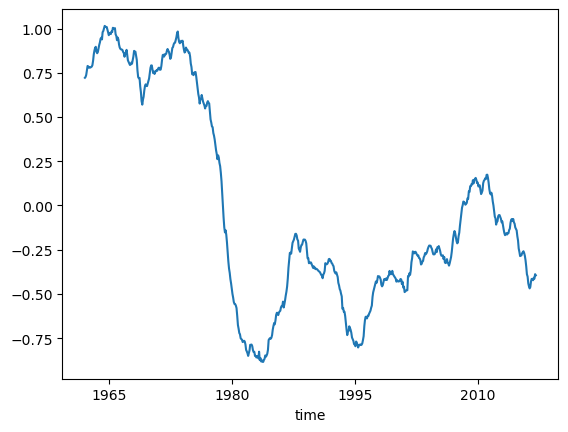

In [64]:
int_anom.sel(lat=slice(-20, -5)).mean(dim='lat').rolling(time=12*8, center=True).mean().plot()

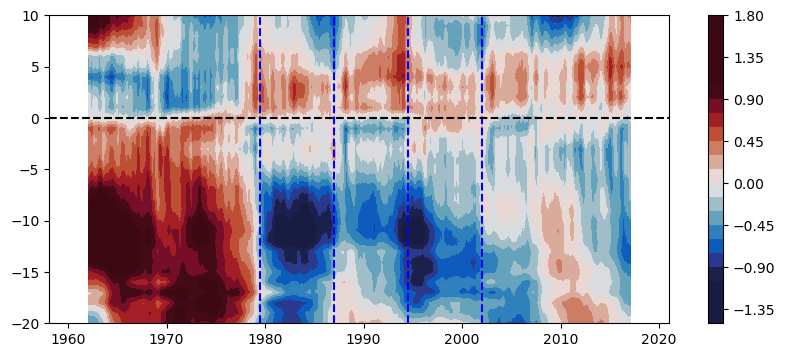

In [356]:
plt.figure(figsize=(10, 4))
plt.contourf(
    time, 
    int_anomalies.lat, 
    int_anomalies.rolling(time=12*8, center=True).mean(),
    vmin=-1, vmax=1, cmap=cmocean.cm.balance, levels=21)
plt.axvline(x=1979.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1987, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1994.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=2002, alpha=1, color='blue',linestyle='dashed')
plt.axhline(y=0, c='k', linestyle='dashed')
plt.colorbar()
plt.show()

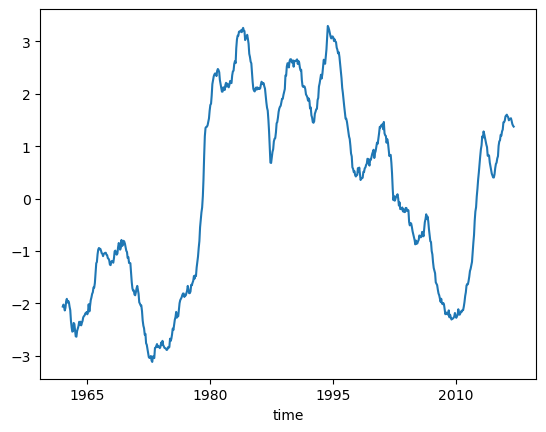

In [67]:
surf_branch_anom.sel(lat=slice(-10, -1)).mean(dim='lat').rolling(time=12*8, center=True).mean().plot()

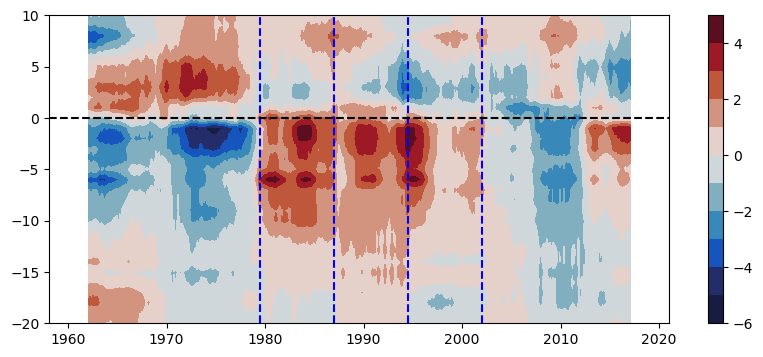

In [362]:
plt.figure(figsize=(10, 4))
plt.contourf(
    time, 
    surf_anomalies.lat, 
    surf_anomalies.rolling(time=12*8, center=True).mean(),
    vmin=-5, vmax=5, cmap=cmocean.cm.balance, levels=10)
plt.axvline(x=1979.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1987, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1994.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=2002, alpha=1, color='blue',linestyle='dashed')
plt.axhline(y=0, c='k', linestyle='dashed')
plt.colorbar()
plt.show()

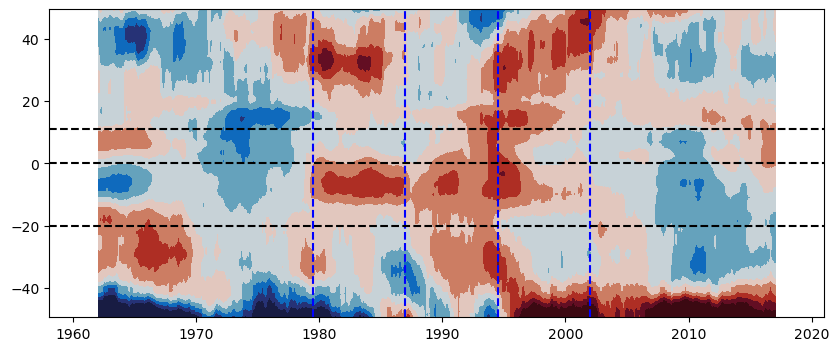

In [360]:
plt.figure(figsize=(10, 4))
plt.contourf(
    time, 
    zonally_integrated_TAUX_anomalies.lat, 
    zonally_integrated_TAUX_anomalies.rolling(time=12*8, center=True).mean().transpose(),
    vmin=-10, vmax=10, cmap=cmocean.cm.balance, levels=21)
plt.axvline(x=1979.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1987, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1994.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=2002, alpha=1, color='blue',linestyle='dashed')
plt.axhline(y=11, c='k', linestyle='dashed')
plt.axhline(y=0, c='k', linestyle='dashed')
plt.axhline(y=-20, c='k', linestyle='dashed')

plt.show()

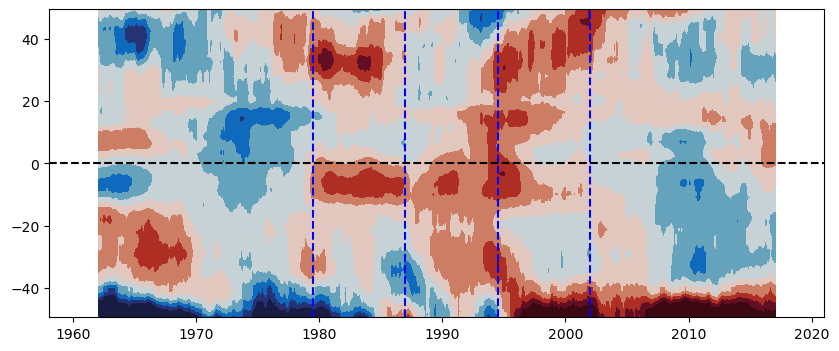

In [326]:
plt.figure(figsize=(10, 4))
plt.contourf(
    time, 
    zonally_integrated_TAUX_anomalies.lat, 
    zonally_integrated_TAUX_anomalies.rolling(time=12*8, center=True).mean().transpose(),
    vmin=-10, vmax=10, cmap=cmocean.cm.balance, levels=21)
plt.axvline(x=1979.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1987, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=1994.5, alpha=1, color='blue',linestyle='dashed')
plt.axvline(x=2002, alpha=1, color='blue',linestyle='dashed')
plt.axhline(y=0, c='k', linestyle='dashed')
plt.show()

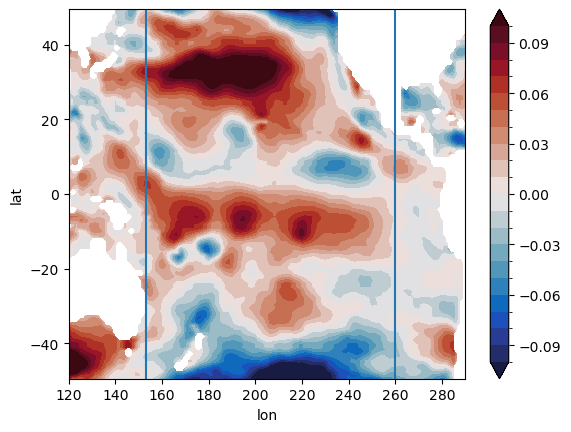

In [265]:
regridded_TAUX_anomalies.sel(lat=slice(-50, 50), 
                             lon=slice(120, 290), 
                             time=slice('1979-06','1987-01')).mean(dim='time').plot.contourf(
    vmin=-0.1, vmax=0.1, levels=21, cmap=cmocean.cm.balance
                             )
plt.axvline(x=153)
plt.axvline(x=260)

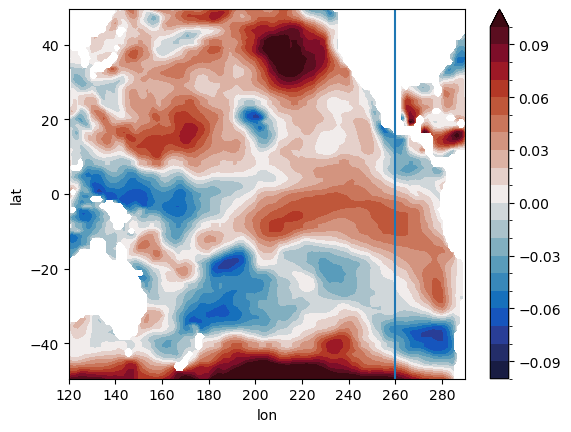

In [266]:
regridded_TAUX_anomalies.sel(lat=slice(-50, 50), 
                             lon=slice(120, 290), 
                             time=slice('1994-06','2002-01')).mean(dim='time').plot.contourf(
    vmin=-0.1, vmax=0.1, levels=21, cmap=cmocean.cm.balance
                             )
plt.axvline(x=260)

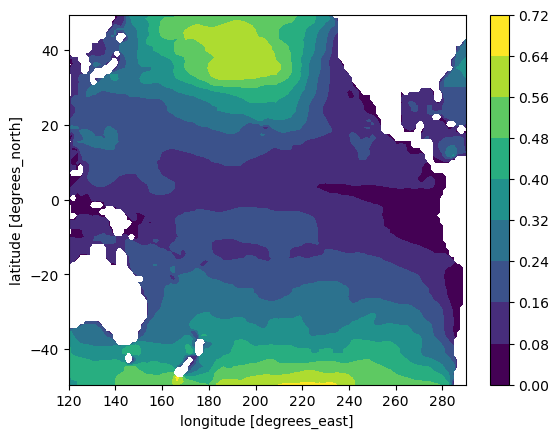

In [198]:
regridded_TAUX_anomalies.sel(lat=slice(-50, 50), 
                             lon=slice(120, 290), 
                             time=slice('1979-06','1987-01')).std(dim='time').plot.contourf(levels=10
    # vmin=-0.1, vmax=0.1, levels=21, cmap=cmocean.cm.balance
                             )

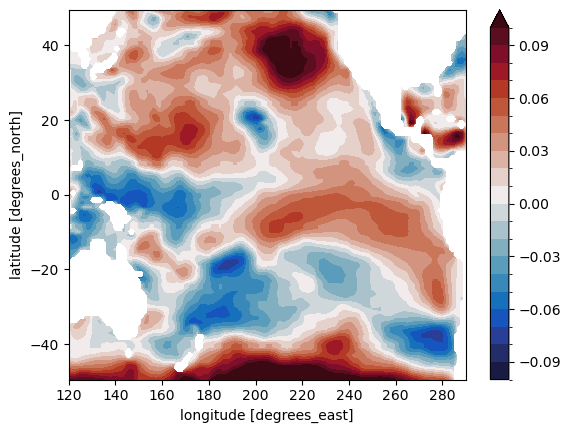

In [196]:
regridded_TAUX_anomalies.sel(lat=slice(-50, 50), 
                             lon=slice(120, 290), 
                             time=slice('1994-06','2002-01')).mean(dim='time').plot.contourf(
    vmin=-0.1, vmax=0.1, levels=21, cmap=cmocean.cm.balance
                             )

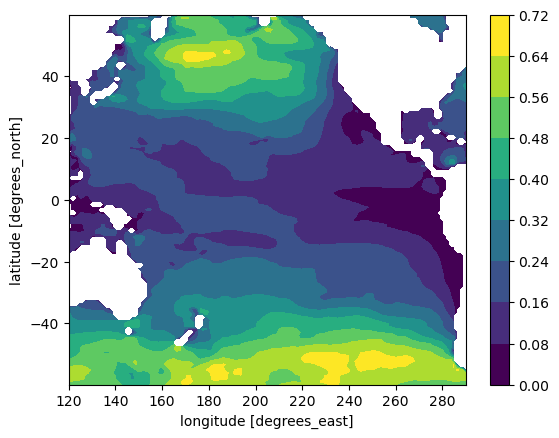

In [186]:
regridded_TAUX_anomalies.sel(lat=slice(-60, 60), 
                             lon=slice(120, 290), 
                             time=slice('1994-06','2002-01')).std(dim='time').plot.contourf(levels=10
    # vmin=-0.1, vmax=0.1, levels=21, cmap=cmocean.cm.balance
                             )

In [379]:
int_convergence_11 = int_anomalies.sel(lat=11, method='nearest') - int_anomalies.sel(lat=-11, method='nearest')
int_convergence_10 = int_anomalies.sel(lat=10, method='nearest') - int_anomalies.sel(lat=-10, method='nearest')
int_convergence_9 = int_anomalies.sel(lat=9, method='nearest') - int_anomalies.sel(lat=-9, method='nearest')
int_convergence_8 = int_anomalies.sel(lat=8, method='nearest') - int_anomalies.sel(lat=-8, method='nearest')
int_convergence_7 = int_anomalies.sel(lat=7, method='nearest') - int_anomalies.sel(lat=-7, method='nearest')
int_convergence_6 = int_anomalies.sel(lat=6, method='nearest') - int_anomalies.sel(lat=-6, method='nearest')
int_convergence_5 = int_anomalies.sel(lat=5, method='nearest') - int_anomalies.sel(lat=-5, method='nearest')
int_convergence_4 = int_anomalies.sel(lat=4, method='nearest') - int_anomalies.sel(lat=-4, method='nearest')
int_convergence_3 = int_anomalies.sel(lat=3, method='nearest') - int_anomalies.sel(lat=-3, method='nearest')
int_convergence_2 = int_anomalies.sel(lat=2, method='nearest') - int_anomalies.sel(lat=-2, method='nearest')
int_convergence_1 = int_anomalies.sel(lat=1, method='nearest') - int_anomalies.sel(lat=-1, method='nearest')

In [415]:
standardize(zonally_integrated_TAUX_anomalies.mean(dim='time'))

<xarray.DataArray (lat: 106)> Size: 848B
array([-1.43295664, -1.56584859, -1.38983645,  0.36185909, -0.86062292,
        0.24126507, -0.04472367, -1.50033193,  1.29529338, -1.38670776,
       -1.20326112,  1.28464111,  0.60846814,  0.24081978, -1.11956474,
       -0.4128909 , -0.0878516 , -0.39488543, -0.23011026, -0.54665021,
        0.83603398, -0.24401512,  1.06749617, -0.74794356, -0.6954373 ,
        0.06440688,  1.14450511,  1.24511888,  0.33267862, -1.92210656,
        0.02169133, -1.14553521,  2.35661681, -0.2952126 ,  0.28705316,
        0.38151409, -1.28782678,  1.53470701, -0.24448365,  0.90077815,
       -2.03776989,  1.34026445, -0.14486116, -1.26345745, -1.3743866 ,
       -0.57804554,  1.02711456,  1.03607857, -0.55262396,  1.48518666,
       -1.4265192 ,  0.47407186,  0.29252063,  0.2466338 , -0.19430842,
        0.51521338,  0.61089791, -0.85841967, -0.62858088, -1.17810574,
       -0.27807449,  0.68103597,  0.78925075,  1.49497205,  1.16600059,
        1.50140368,  1.21832486, -0.15538371, -0.31845707,  0.87558018,
        0.67388412,  1.8415366 , -2.31568134,  0.85008018, -0.4058707 ,
       -1.74748307,  0.89786436, -0.28408406,  0.58370482,  0.89720513,
       -0.27573572,  0.14597357, -0.23506273,  0.77422684,  0.12172621,
       -0.19444008, -1.99135064,  1.25710437, -1.53613763, -0.95983884,
       -0.16461296,  0.45084869,  0.88455387,  0.11978336,  0.34101922,
        0.70431142,  0.94196807,  0.47939412, -1.47774185, -0.3361276 ,
       -0.70771974,  1.78611074, -0.86724429, -0.92009904,  0.7229403 ,
        0.73329441])
Coordinates:
  * lat      (lat) float64 848B -49.48 -48.53 -47.59 ... 47.59 48.53 49.48

In [76]:
ens_ind = 0
TAUX_lens = afuncs.atm_var_ens(ens_ind, 'TAUX')
PRECT_ds = afuncs.atm_var_ens(ens_ind, 'PRECT')

In [483]:
zonally_integrated_TAUX_lens = (TAUX_lens
                                    .sel(lat=slice(-50, 50), lon=slice(120, 290))
                                    .fillna(0)
                                    .integrate('lon'))

zonally_integrated_PRECT_lens = (PRECT_ds
                                    .sel(lat=slice(-50, 50), lon=slice(120, 290))
                                    .fillna(0)
                                    .integrate('lon'))

In [459]:
# ens_memb_index = 0
# transport_Sv_nan = xr.open_dataset(
#     '/glade/derecho/scratch/cassiacai/lens_transport_{}.nc'.format(
#         ens_memb_index)).__xarray_dataarray_variable__

file_paths = [f'/glade/derecho/scratch/cassiacai/lens_transport_{i}.nc' for i in range(100)]
ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)
ds.coords['ensemble'] = range(100)
transport_Sv_nan = ds['__xarray_dataarray_variable__'].compute()

all_int_ts = []; all_wbc_ts = []

for lat_ind in range(32):
    int_ts = transport_Sv_nan[:, :, lat_ind, wbc_boundary_nlon_indx_ls[lat_ind]:].dropna(dim='nlon').integrate('ULONG')
    wbc_ts = transport_Sv_nan[:, :, lat_ind, :wbc_boundary_nlon_indx_ls[lat_ind]].dropna(dim='nlon').integrate('ULONG')
    all_int_ts.append(int_ts)
    all_wbc_ts.append(wbc_ts)

wbc_array = xr.DataArray(np.array(all_wbc_ts), 
                            dims=('lat', 'ensemble', 'time'), 
                            coords={'lat': np.linspace(-20, 11, 32), 
                                    'ensemble':np.arange(100), 
                                    'time': transport_Sv_nan.time})

int_array = xr.DataArray(np.array(all_int_ts), 
                            dims=('lat', 'ensemble', 'time'), 
                            coords={'lat': np.linspace(-20, 11, 32), 
                                    'ensemble':np.arange(100), 
                                    'time': transport_Sv_nan.time})

# time_coords = transport_Sv_nan.time.dt.year + transport_Sv_nan.time.dt.month/12

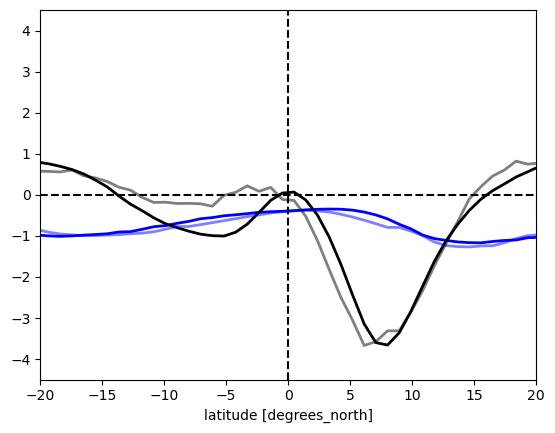

In [484]:
standardize(zonally_integrated_TAUX_lens.mean(dim='time')*-1).plot(c='blue', linewidth=2)
standardize(zonally_integrated_PRECT_lens.mean(dim='time')*-1).plot(c='k', linewidth=2)

standardize(zonally_integrated_TAUX.mean(dim='time')).plot(c='blue', linewidth=2, alpha=0.5)
standardize(zonally_integrated_PREC_F.mean(dim='time')*-1).plot(c='k', linewidth=2, alpha=0.5)


plt.xlim(-20, 20)
plt.ylim(-4.5, 4.5)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.axvline(x=0, c='k', linestyle='dashed')
plt.show()

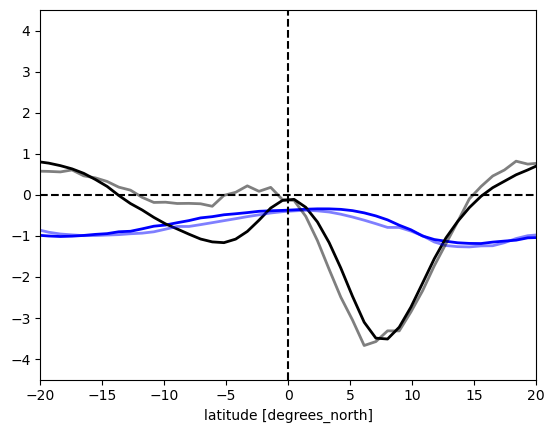

In [458]:
standardize(zonally_integrated_TAUX_lens.mean(dim='time')*-1).plot(c='blue', linewidth=2)
standardize(zonally_integrated_PRECT_lens.mean(dim='time')*-1).plot(c='k', linewidth=2)

standardize(zonally_integrated_TAUX.mean(dim='time')).plot(c='blue', linewidth=2, alpha=0.5)
standardize(zonally_integrated_PREC_F.mean(dim='time')*-1).plot(c='k', linewidth=2, alpha=0.5)


plt.xlim(-20, 20)
plt.ylim(-4.5, 4.5)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.axvline(x=0, c='k', linestyle='dashed')
plt.show()

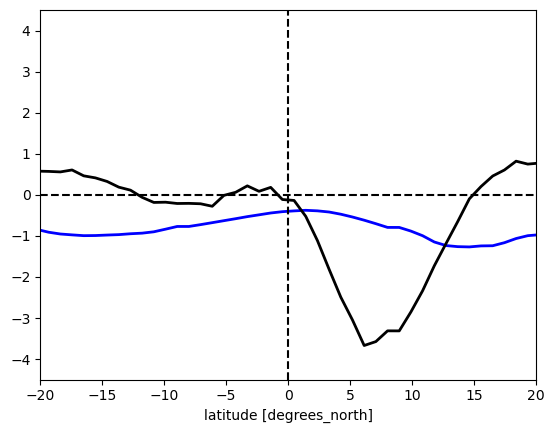

In [487]:
standardize(zonally_integrated_TAUX.mean(dim='time')).plot(c='blue', linewidth=2)
standardize(zonally_integrated_PREC_F.mean(dim='time')*-1).plot(c='k', linewidth=2)

plt.xlim(-20, 20)
plt.ylim(-4.5, 4.5)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.axvline(x=0, c='k', linestyle='dashed')
plt.show()

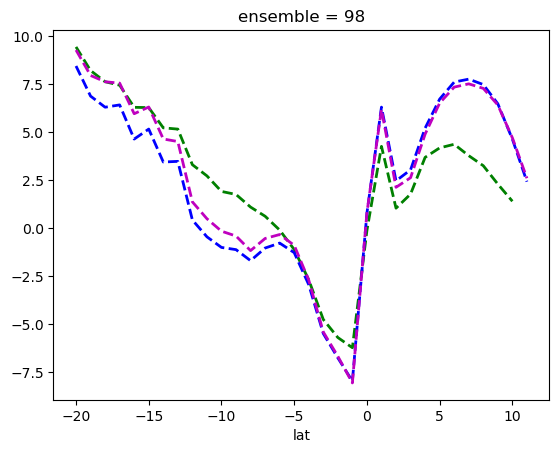

In [485]:
int_ds[:,:].mean(dim='time').plot(c='green', linestyle='dashed', linewidth=2)
int_array[:,91].mean(dim='time').plot(c='blue', linestyle='dashed', linewidth=2)
int_array[:,98].mean(dim='time').plot(c='m', linestyle='dashed', linewidth=2)

In [467]:
int_array_diff = standardize(int_array[:,:].mean(dim='time')) - standardize(int_ds[:,:].mean(dim='time')) 

In [480]:
np.abs(int_array_diff).mean(dim='lat').argmin()

<xarray.DataArray ()> Size: 8B
array(98)

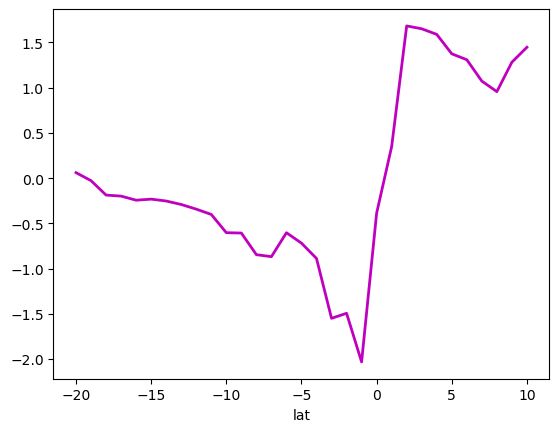

In [442]:
standardize(surf_ds[:,:].mean(dim='time')).plot(c='m', linewidth=2)


In [ ]:
surf_ds

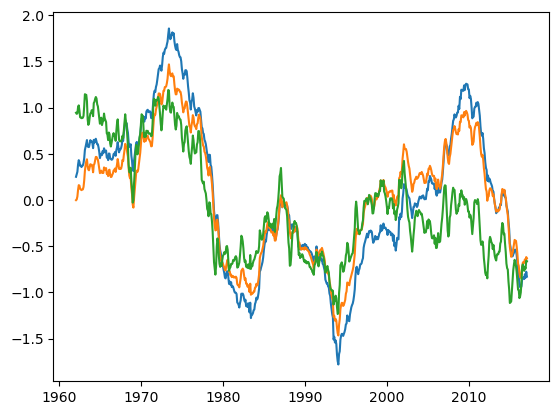

In [384]:
plt.plot(time, int_convergence_11.rolling(
    time=12*8, center=True).mean()*-1)
plt.plot(time, int_convergence_9.rolling(
    time=12*8, center=True).mean()*-1)

plt.plot(time, int_convergence_6.rolling(
    time=12*8, center=True).mean()*-1)

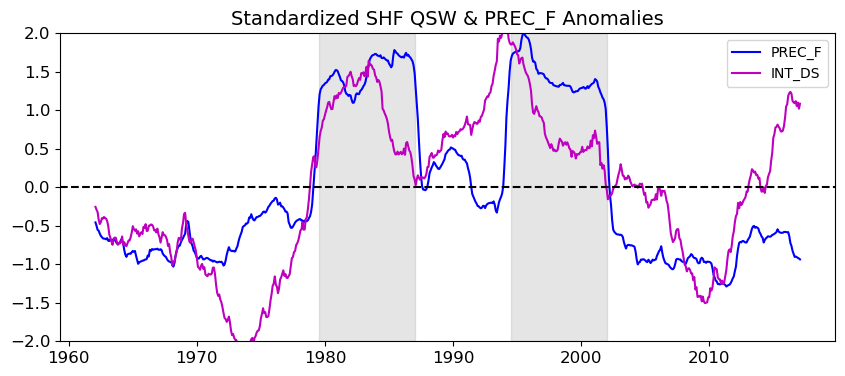

In [390]:
plt.figure(figsize=(10, 4))
plt.title('Standardized SHF QSW & PREC_F Anomalies', fontsize=14)
# plt.plot(time, standardize(SEP_SHF_QSW_anom.mean(dim=["lat", "lon"]).rolling(
#     time=12*8, center=True).mean()*-1), c='red', label='SHF QSW')
# plt.plot(time, standardize(SEP_TEMP_anom.mean(dim=["lat", "lon"]).rolling(
#     time=12*8, center=True).mean()), c='green', linewidth=3, alpha=0.5, label='TEMP')
plt.plot(time, standardize(SEP_PREC_F_anom.mean(dim=["lat", "lon"]).rolling(
    time=12*8, center=True).mean()), c='blue', label='PREC_F')

plt.plot(time, standardize(int_convergence_11.rolling(
    time=12*8, center=True).mean()), c='m', label='INT_DS')

plt.ylim(-2, 2)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()

plt.axvspan(1979.5, 1987, alpha=0.2, color='gray')
plt.axvspan(1994.5, 2002, alpha=0.2, color='gray')
plt.show()

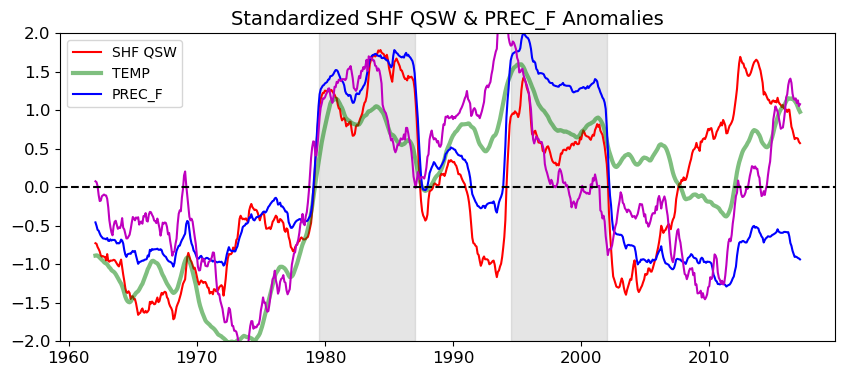

In [387]:
plt.figure(figsize=(10, 4))
plt.title('Standardized SHF QSW & PREC_F Anomalies', fontsize=14)
plt.plot(time, standardize(SEP_SHF_QSW_anom.mean(dim=["lat", "lon"]).rolling(
    time=12*8, center=True).mean()*-1), c='red', label='SHF QSW')
plt.plot(time, standardize(SEP_TEMP_anom.mean(dim=["lat", "lon"]).rolling(
    time=12*8, center=True).mean()), c='green', linewidth=3, alpha=0.5, label='TEMP')
plt.plot(time, standardize(SEP_PREC_F_anom.mean(dim=["lat", "lon"]).rolling(
    time=12*8, center=True).mean()), c='blue', label='PREC_F')

plt.plot(time, standardize(int_convergence_9.rolling(
    time=12*8, center=True).mean()), c='m')

plt.ylim(-2, 2)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()

plt.axvspan(1979.5, 1987, alpha=0.2, color='gray')
plt.axvspan(1994.5, 2002, alpha=0.2, color='gray')
plt.show()

In [76]:
##### One specific member
# ENS_MEMB = 19

# PRECT_ds = afuncs.atm_var_ens(ENS_MEMB, 'PRECT')
# area_weighted_PRECT = PRECT_ds*CESMLENS_var
# DII_LENS = calculate_DII(area_weighted_PRECT)
# DII_LENS_anomalies = remove_climatology(DII_LENS)

DII_LENS = xr.open_dataset(
    'DII_results/area_avg_DII_all_members.nc').__xarray_dataarray_variable__
DII_LENS_anomalies = remove_climatology(DII_LENS)

In [78]:
DII_diff = np.abs(DII_LENS - DII_FOSI)

# print(DII_diff.sel(time=slice('1960-01', '1995-01')).mean(dim='time').argmin().item())
# print(DII_diff.sel(time=slice('1960-01', '1995-01')).mean(dim='time').argmax().item())

# print(DII_diff.sel(time=slice('1995-01', '2015-01')).mean(dim='time').argmin().item())
# print(DII_diff.sel(time=slice('1995-01', '2015-01')).mean(dim='time').argmax().item())

dii_means_end = DII_diff.sel(time=slice('1995-01','2015-12')).mean(dim='time')
dii_means_begin = DII_diff.sel(time=slice('1958-01','1995-01')).mean(dim='time')

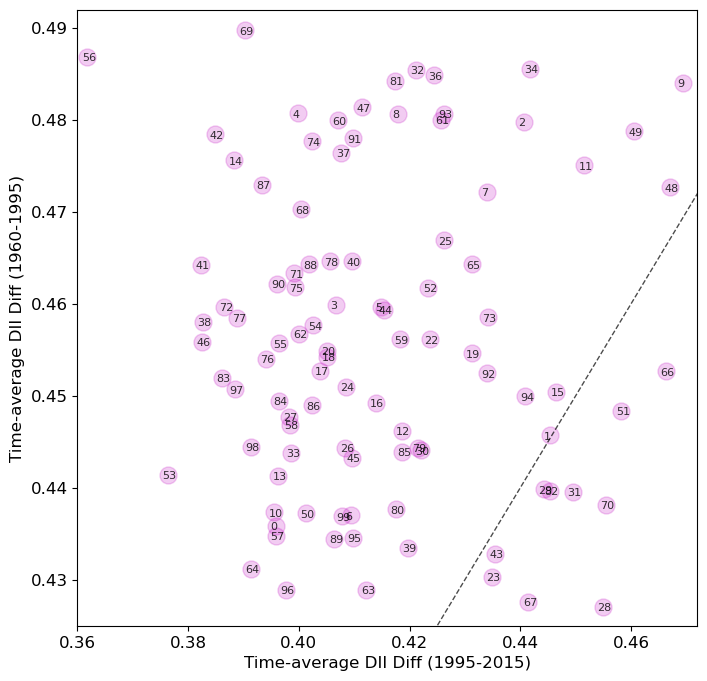

In [198]:
plt.figure(figsize=(8, 8))
plt.scatter(dii_means_end, dii_means_begin, edgecolor='m', facecolor='m', alpha=0.2, s=150)
plt.ylim(0.425, 0.492)
plt.xlim(0.36, 0.472)
plt.ylabel('Time-average DII Diff (1960-1995)', fontsize=12)
plt.xlabel('Time-average DII Diff (1995-2015)', fontsize=12)
plt.plot([0.4, 0.5], [0.4, 0.5], 'k--', alpha=0.7, linewidth=1)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
plt.gca().xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

threshold = 0.0

for i, (x, y) in enumerate(zip(dii_means_end, dii_means_begin)):
    distance_from_diagonal = abs(x - y)
    if distance_from_diagonal > threshold:
        plt.annotate(str(i), (x, y), 
                    xytext=(-4, -3), 
                    textcoords='offset points',
                    fontsize=8,
                    alpha=0.8,
                    color='k')

plt.show()

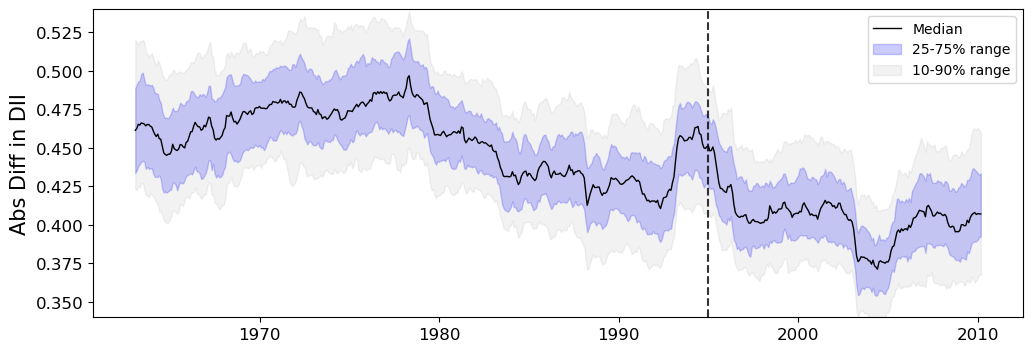

In [151]:
time = DII_diff.time.dt.year + DII_diff.time.dt.month/12

plt.figure(figsize=(12, 4))
percentiles = DII_diff.rolling(time=12*10, center=True).mean().quantile(
    [0.1, 0.25, 0.5, 0.75, 0.9], dim='ensemble_member'
)
plt.plot(time, percentiles.sel(quantile=0.5), color='black', linewidth=1, label='Median')
plt.fill_between(time,
                percentiles.sel(quantile=0.25),
                percentiles.sel(quantile=0.75),
                alpha=0.2, color='blue', label='25-75% range')
plt.fill_between(time,
                percentiles.sel(quantile=0.1),
                percentiles.sel(quantile=0.9),
                alpha=0.1, color='gray', label='10-90% range')
# plt.plot(time, DII_diff[9,:].rolling(time=12*10, center=True).mean(), c='red', linewidth=1)
# plt.plot(time, DII_diff[98,:].rolling(time=12*10, center=True).mean(), c='green', linewidth=1)
# plt.plot(time, DII_diff[21,:].rolling(time=12*10, center=True).mean(), c='darkgreen', linewidth=1, linestyle='dashed')
# plt.plot(time, DII_diff[56,:].rolling(time=12*10, center=True).mean(), c='green', linewidth=1)

# plt.plot(time, DII_diff[69,:].rolling(time=12*10, center=True).mean(), c='darkred', linewidth=1, linestyle='dashed')
# plt.plot(time, DII_diff[9,:].rolling(time=12*10, center=True).mean(), c='red', linewidth=1)

plt.ylabel('Abs Diff in DII', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.ylim(0.34, 0.54)
# plt.axhline(y=0, c='k', linestyle='dashed', alpha=0.8)
plt.axvline(x=1995,c='k', linestyle='dashed', alpha=0.8)
plt.show()

In [199]:
wbc_boundary_nlon_indx_ls = [64, 65, 80, 54, 79, 48, 48, 48, 56, 56, 
                             55, 55, 55, 54, 55, 55, 54, 57, 53, 51, 
                             53, 52, 34, 34, 35, 33, 31, 32, 32, 32, 
                             31, 31] # WBC from piControl

# ens_memb_index = 0
# transport_Sv_nan = xr.open_dataset(
#     '/glade/derecho/scratch/cassiacai/lens_transport_{}.nc'.format(
#         ens_memb_index)).__xarray_dataarray_variable__

file_paths = [f'/glade/derecho/scratch/cassiacai/lens_transport_{i}.nc' for i in range(100)]
ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)
ds.coords['ensemble'] = range(100)
transport_Sv_nan = ds['__xarray_dataarray_variable__'].compute()

all_int_ts = []; all_wbc_ts = []

for lat_ind in range(32):
    int_ts = transport_Sv_nan[:, :, lat_ind, wbc_boundary_nlon_indx_ls[lat_ind]:].dropna(dim='nlon').integrate('ULONG')
    wbc_ts = transport_Sv_nan[:, :, lat_ind, :wbc_boundary_nlon_indx_ls[lat_ind]].dropna(dim='nlon').integrate('ULONG')
    all_int_ts.append(int_ts)
    all_wbc_ts.append(wbc_ts)

wbc_array = xr.DataArray(np.array(all_wbc_ts), 
                            dims=('lat', 'ensemble', 'time'), 
                            coords={'lat': np.linspace(-20, 11, 32), 
                                    'ensemble':np.arange(100), 
                                    'time': transport_Sv_nan.time})

int_array = xr.DataArray(np.array(all_int_ts), 
                            dims=('lat', 'ensemble', 'time'), 
                            coords={'lat': np.linspace(-20, 11, 32), 
                                    'ensemble':np.arange(100), 
                                    'time': transport_Sv_nan.time})

# time_coords = transport_Sv_nan.time.dt.year + transport_Sv_nan.time.dt.month/12

In [80]:
field = 'PV'

fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
ds_smyle_fosi_var = xr.open_dataset(fpath+fname)[field]
ds_smyle_fosi_var['time'] = fosi_montime_vals
ds_smyle_fosi_var = ds_smyle_fosi_var.sel(time=slice('1958-01', '2015-01')).isel(z_t = 15)
PV_fosi = ds_smyle_fosi_var.compute()
fosi_1deg_wzeros_var = proc_utils.regrid_SMYLE(PV_fosi)
regridded_PV = regridder(fosi_1deg_wzeros_var)
regridded_PV['time'] = regridded_PV.sel(time=slice('1958-01', '2015-01'))['time']

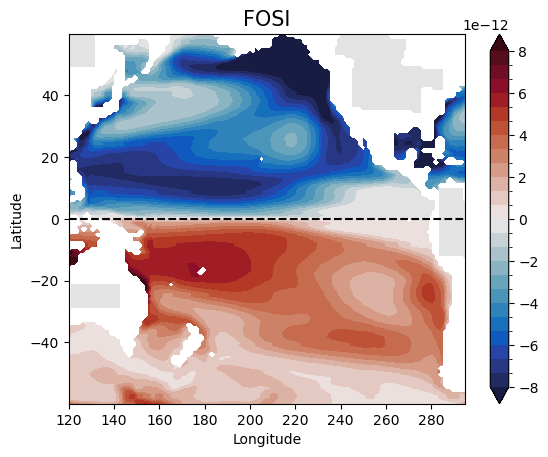

In [84]:
regridded_PV.sel(
    lat=slice(-60, 60), lon=slice(120, 295)).mean(dim='time').plot.contourf(
    levels=25,vmin=-8e-12, vmax=8e-12, cmap=cmocean.cm.balance)
plt.title('FOSI', fontsize=15)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [49]:
ens_ind = 1
PV_lens = ocn_var_ens(ens_ind, 'PV')
PV_Lens_compute = PV_lens.isel(z_t = 20).compute()
fosi_1deg_wzeros_var = proc_utils.regrid_SMYLE(PV_Lens_compute)
regridded_PV_lens = regridder(fosi_1deg_wzeros_var)

In [22]:
%%time
regridded_PV_lens_21 = load_PV_lens(21)

CPU times: user 41.4 s, sys: 1.06 s, total: 42.4 s
Wall time: 1min 53s


In [23]:
regridded_PV_lens_21 = load_PV_lens(21)
regridded_PV_lens_69 = load_PV_lens(69)

In [86]:
regridded_PV_lens_21 = load_PV_lens(21)
regridded_PV_lens_69 = load_PV_lens(69)
regridded_PV_lens_9 = load_PV_lens(9)
regridded_PV_lens_10 = load_PV_lens(10)
regridded_PV_lens_11 = load_PV_lens(11)
regridded_PV_lens_12 = load_PV_lens(12)
regridded_PV_lens_97 = load_PV_lens(97)
regridded_PV_lens_98 = load_PV_lens(98)

In [87]:
LENS_PV = xr.concat([regridded_PV_lens_69.mean(dim='time'), 
                     regridded_PV_lens_21.mean(dim='time'),
                     regridded_PV_lens_9.mean(dim='time'), 
                     regridded_PV_lens_10.mean(dim='time'), 
                     regridded_PV_lens_11.mean(dim='time'), 
                     regridded_PV_lens_12.mean(dim='time'), 
                     regridded_PV_lens_97.mean(dim='time'), 
                     regridded_PV_lens_98.mean(dim='time'), 
                    ], dim='ens')

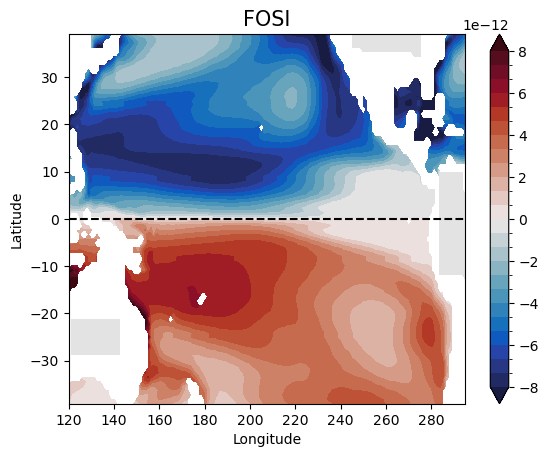

In [88]:
regridded_PV.mean(dim='time').sel(
    lat=slice(-40, 40), lon=slice(120, 295)).plot.contourf(
    levels=25,vmin=-8e-12, vmax=8e-12, cmap=cmocean.cm.balance)
plt.title('FOSI', fontsize=15)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

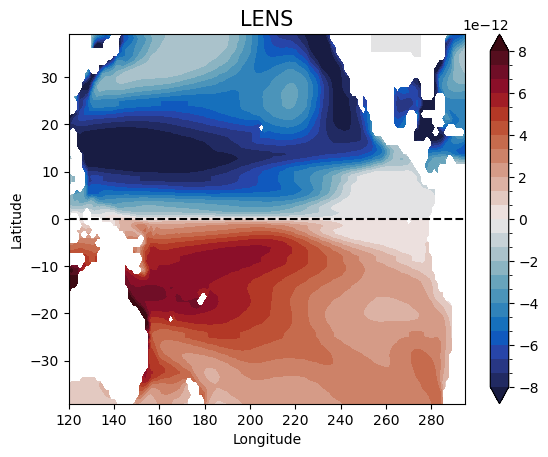

In [89]:
LENS_PV.mean(dim='ens').sel(
    lat=slice(-40, 40), lon=slice(120, 295)).plot.contourf(
    levels=25,vmin=-8e-12, vmax=8e-12, cmap=cmocean.cm.balance)
plt.title('LENS', fontsize=15)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

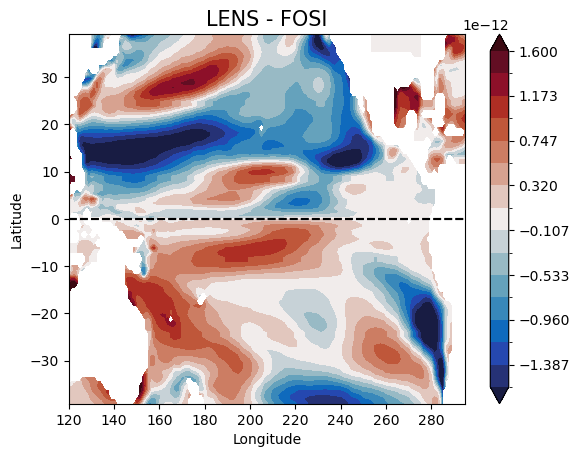

CPU times: user 232 ms, sys: 3.73 ms, total: 236 ms
Wall time: 263 ms


In [92]:
%%time
(LENS_PV.mean(dim='ens') - regridded_PV.mean(dim='time')).sel(
    lat=slice(-40, 40), lon=slice(120, 295)).plot.contourf(
    levels=16,vmin=-1.6e-12, vmax=1.6e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.title('LENS - FOSI', fontsize=15)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

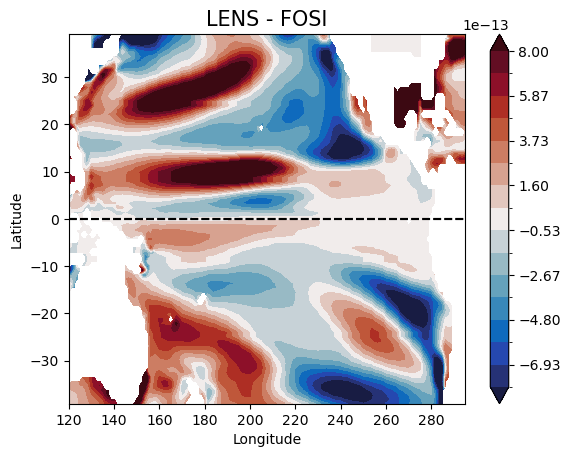

CPU times: user 236 ms, sys: 0 ns, total: 236 ms
Wall time: 263 ms


In [67]:
%%time
(LENS_PV.mean(dim='ens') - regridded_PV.mean(dim='time')).sel(
    lat=slice(-40, 40), lon=slice(120, 295)).plot.contourf(
    levels=16,vmin=-0.8e-12, vmax=0.8e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.title('LENS - FOSI', fontsize=15)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

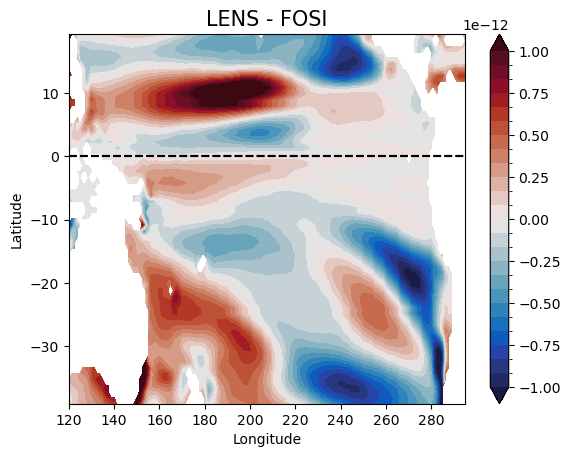

CPU times: user 522 ms, sys: 0 ns, total: 522 ms
Wall time: 592 ms


In [49]:
%%time
(LENS_PV.mean(dim='ens') - regridded_PV.mean(dim='time')).sel(
    lat=slice(-40, 20), lon=slice(120, 295)).plot.contourf(
    levels=25,vmin=-1e-12, vmax=1e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.title('LENS - FOSI', fontsize=15)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [26]:
%%time
(regridded_PV_lens_21 - regridded_PV_lens).sel(
    lat=slice(-60, 60), lon=slice(120, 280), time=slice('1960-01','2015-01')).mean(dim='time').plot.contourf(
    levels=25,vmin=-0.5e-12, vmax=0.5e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.show()

NameError: name 'regridded_PV_lens' is not defined

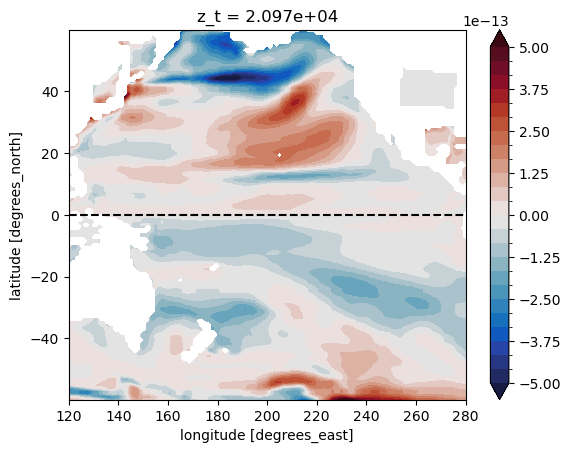

CPU times: user 162 ms, sys: 19.9 ms, total: 182 ms
Wall time: 246 ms


In [95]:
%%time
(regridded_PV_lens_69 - regridded_PV_lens_21).sel(
    lat=slice(-60, 60), lon=slice(120, 280), time=slice('1960-01','2015-01')).mean(dim='time').plot.contourf(
    levels=25,vmin=-0.5e-12, vmax=0.5e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.show()

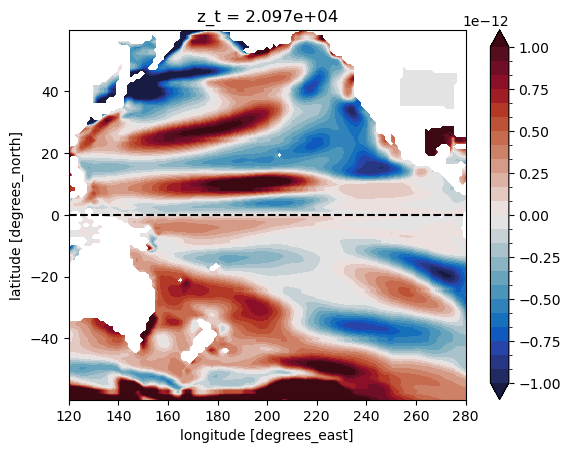

CPU times: user 192 ms, sys: 19.9 ms, total: 212 ms
Wall time: 259 ms


In [90]:
%%time
(regridded_PV_lens_21 - regridded_PV).sel(
    lat=slice(-60, 60), lon=slice(120, 280), time=slice('1960-01','2015-01')).mean(dim='time').plot.contourf(
    levels=25,vmin=-1e-12, vmax=1e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.show()

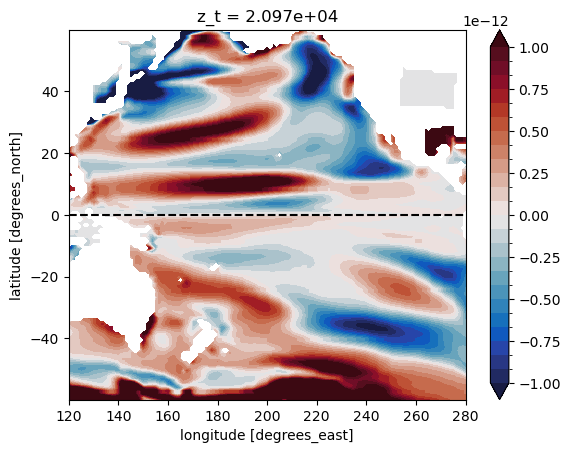

In [91]:
(regridded_PV_lens - regridded_PV).sel(
    lat=slice(-60, 60), lon=slice(120, 280), time=slice('1960-01','2015-01')).mean(dim='time').plot.contourf(
    levels=25,vmin=-1e-12, vmax=1e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.show()

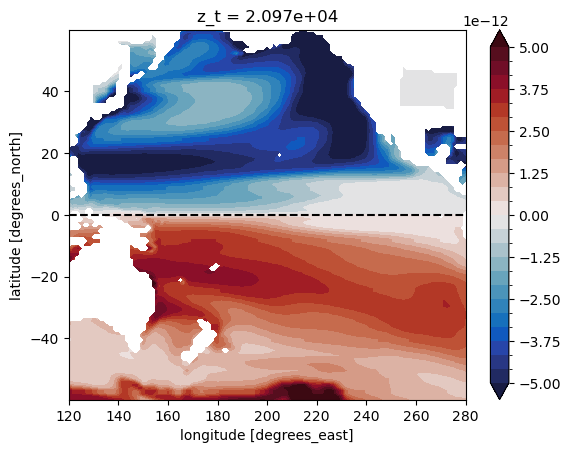

In [92]:
regridded_PV_lens.sel(
    lat=slice(-60, 60), lon=slice(120, 280), time=slice('1960-01','2015-01')).mean(dim='time').plot.contourf(
    levels=25,vmin=-5e-12, vmax=5e-12, cmap=cmocean.cm.balance)
plt.axhline(y=0, c='k', linestyle='dashed')
plt.show()

In [211]:
dii_means_begin.argsort()

<xarray.DataArray (ensemble_member: 100)> Size: 800B
array([21, 35, 28, 67, 63, 96, 23, 64, 43, 39, 89, 95, 57,  0, 99,  6, 50,
       10, 80, 70, 31, 82, 29, 13, 53, 45, 33, 85, 30, 26, 79, 98,  1, 12,
       58, 27, 51, 86, 16, 84, 94, 15, 97, 24, 83, 92, 66, 17, 76, 18, 19,
       20, 55, 46, 22, 59, 62, 54, 38, 77, 73, 44, 72,  5,  3, 52, 75, 90,
       71, 41, 88, 65, 78, 40, 25, 68,  7, 48, 87, 11, 14, 37, 74, 91, 42,
       49,  2, 60, 61,  8, 93,  4, 47,  9, 81, 36, 32, 34, 56, 69])
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 0 1 2 3 4 5 ... 95 96 97 98 99

In [84]:
print(dii_means_begin[21])
print(dii_means_begin[69])


<xarray.DataArray ()> Size: 4B
array(0.41345, dtype=float32)
Coordinates:
    ensemble_member  int64 8B 21
<xarray.DataArray ()> Size: 4B
array(0.48975772, dtype=float32)
Coordinates:
    ensemble_member  int64 8B 69


In [210]:
dii_means_end.argsort()

<xarray.DataArray (ensemble_member: 100)> Size: 800B
array([56, 53, 41, 46, 38, 42, 83, 72, 14, 97, 77, 69, 98, 64, 87, 76, 10,
       57,  0, 90, 13, 84, 55, 96, 27, 58, 33, 71, 75,  4, 62, 68, 50, 88,
       86, 74, 54, 17, 20, 18, 78, 89, 21,  3, 60, 37, 99, 26, 24,  6, 45,
       40, 95, 91, 47, 63, 16,  5, 44, 81, 80,  8, 59, 12, 85, 39, 32, 79,
       30, 52, 22, 36, 61, 25, 93, 19, 65, 35,  7, 92, 73, 23, 43,  2, 94,
       67, 34, 29,  1, 82, 15, 31, 11, 28, 70, 51, 49, 66, 48,  9])
Coordinates:
  * ensemble_member  (ensemble_member) int64 800B 0 1 2 3 4 5 ... 95 96 97 98 99

In [213]:
int_array.sel(lat=-10, method='nearest')

<xarray.DataArray (ensemble: 100, time: 685)> Size: 548kB
array([[-3.80331422, -3.78613101,  4.23982994, ...,  2.28515248,
        -2.46188743, -1.75625437],
       [-5.52796327, -3.42858756,  2.65931706, ...,  2.7360906 ,
         0.19864645, -4.6103163 ],
       [-1.29609177, -3.29932927,  1.07302369, ...,  1.58129639,
        -2.32510192, -5.62176439],
       ...,
       [-4.4190732 , -3.29473272,  0.30794824, ..., -2.24541746,
        -4.05349653, -4.89887084],
       [-7.40737608, -3.36345472, -0.27893673, ...,  0.01100427,
         0.22871194, -3.60634797],
       [-4.3780807 , -1.4704434 ,  3.33055364, ...,  4.31394021,
         0.07315076, -4.98398493]])
Coordinates:
    lat       float64 8B -10.0
  * ensemble  (ensemble) int64 800B 0 1 2 3 4 5 6 7 ... 92 93 94 95 96 97 98 99
  * time      (time) object 5kB 1958-01-01 00:00:00 ... 2015-01-01 00:00:00

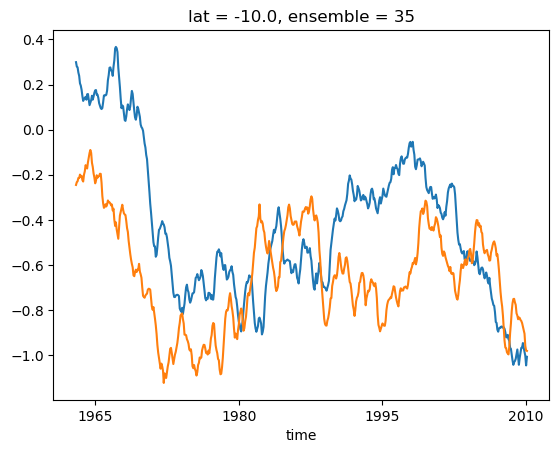

In [216]:
int_array.sel(lat=-10, method='nearest')[21,:].rolling(time=12*10, center=True).mean().plot()
int_array.sel(lat=-10, method='nearest')[35,:].rolling(time=12*10, center=True).mean().plot()

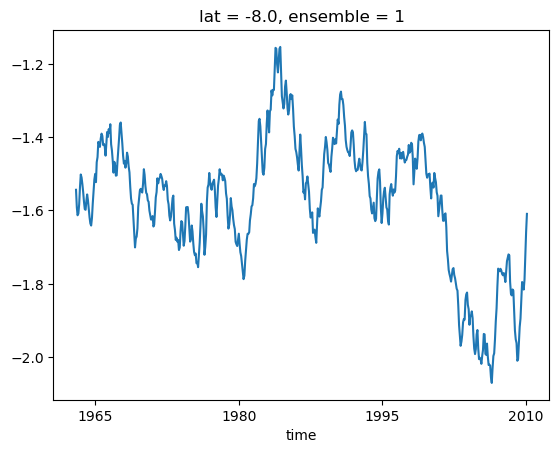

In [219]:
int_array.sel(lat=-8, method='nearest')[1,:].rolling(time=12*10, center=True).mean().plot()
